# 02 - EDA base

Proyecto: Prediccion de caida critica de produccion mensual en pozos no convencionales de petroleo y gas.

Objetivo de este notebook: realizar la primera parte del EDA sobre la base procesada, enfocada en cobertura temporal, produccion mensual agregada y categorias principales.

Alcance de esta etapa:
- No se crea todavia el target `caida_critica`.
- No se entrenan modelos.
- No se hace feature engineering avanzado.
- No se unen otros datasets.
- Los graficos principales se guardan en `../reports/figures/`.

## 1. Importacion de librerias y configuracion

Se cargan librerias de analisis tabular y visualizacion. Tambien se define la carpeta de salida para figuras.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 2. Carga del dataset base

Se utiliza la version base procesada generada en el notebook de calidad de datos. Esta base solo incluye correcciones minimas: nombres de columnas normalizados, fechas convertidas y duplicados exactos eliminados si correspondia.

In [2]:
DATA_PATH = Path("../data/processed/produccion_no_convencional_base.csv")

df = pd.read_csv(
    DATA_PATH,
    low_memory=False,
    parse_dates=["fecha_data", "fechaingreso"],
)

df_eda = df.copy()
df_eda["periodo_mes"] = df_eda["fecha_data"].dt.to_period("M").dt.to_timestamp()

print(f"Filas: {df_eda.shape[0]:,}")
print(f"Columnas: {df_eda.shape[1]:,}")
df_eda.head()

Filas: 405,996
Columnas: 41


,idempresa,anio,mes,idpozo,prod_pet,prod_gas,prod_agua,iny_agua,iny_gas,iny_co2,iny_otro,tef,vida_util,tipoextraccion,tipoestado,tipopozo,observaciones,fechaingreso,rectificado,habilitado,idusuario,empresa,sigla,formprod,profundidad,formacion,idareapermisoconcesion,areapermisoconcesion,idareayacimiento,areayacimiento,cuenca,provincia,coordenadax,coordenaday,tipo_de_recurso,proyecto,clasificacion,subclasificacion,sub_tipo_recurso,fecha_data,periodo_mes
0,YSUR,2016,1,135204,0.00,59.94,28.35,0.00,0.00,0.00,0.00,30.81,NaN,Plunger Lift,Extracción Efectiva,Gasífero,NaN,2016-02-17 10:50:46.929347,f,t,5,YSUR ENERGÍA ARGENTINA S.R.L.,APA.Nq.ACO-13(d),PREC,"3,500.00",precuyo,ANC,ANTICLINAL CAMPAMENTO,ACO,ANTICLINAL CAMPAMENTO OESTE,NEUQUINA,Neuquén,-69.79,-38.97,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2016-01-31,2016-01-01
1,YSUR,2018,1,155584,80.81,786.90,0.00,0.00,0.00,0.00,0.00,31.00,NaN,Surgencia Natural,Extracción Efectiva,Gasífero,NaN,2018-02-10 08:37:14.717426,f,t,444,YSUR ENERGÍA ARGENTINA S.R.L.,YSR.RN.EFO-262(d),LAJA,"3,847.00",lajas,FEO,ESTACION FERNANDEZ ORO,Z155,ESTACION FERNANDEZ ORO,NEUQUINA,Rio Negro,-67.80,-39.03,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2018-01-31,2018-01-01
2,YSUR,2015,1,135203,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,Sin Sistema de Extracción,Parado Transitoriamente,Gasífero,NaN,2015-02-26 13:35:35.533458,f,t,5,YSUR ENERGÍA ARGENTINA S.R.L.,APA.Nq.ACO-12(d),PREC,"3,617.00",precuyo,ANC,ANTICLINAL CAMPAMENTO,ACO,ANTICLINAL CAMPAMENTO OESTE,NEUQUINA,Neuquén,-69.81,-38.96,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2015-01-31,2015-01-01
3,YSUR,2017,1,155582,58.28,608.01,13.63,0.00,0.00,0.00,0.00,31.00,NaN,Surgencia Natural,Extracción Efectiva,Gasífero,NaN,2017-02-16 13:45:37.233373,f,t,444,YSUR ENERGÍA ARGENTINA S.R.L.,YSR.RN.EFO-245(d),LAJA,"3,805.00",lajas,FEO,ESTACION FERNANDEZ ORO,Z155,ESTACION FERNANDEZ ORO,NEUQUINA,Rio Negro,-67.85,-39.01,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2017-01-31,2017-01-01
4,YSUR,2016,1,136137,0.00,432.17,45.52,0.00,0.00,0.00,0.00,31.00,NaN,Surgencia Natural,Extracción Efectiva,Gasífero,NaN,2016-02-17 10:50:46.929347,f,t,5,YSUR ENERGÍA ARGENTINA S.R.L.,APA.Nq.Gu-1199(d),PREC,"3,375.00",precuyo,NDD,AL NORTE DE LA DORSAL,GUA,GUANACO,NEUQUINA,Neuquén,-69.22,-38.87,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2016-01-31,2016-01-01


## 3. Validaciones generales

Antes de graficar, se revisan dimensiones, columnas clave, tipos de datos, rango temporal y cantidad de pozos unicos.

In [3]:
key_columns = [
    "idpozo", "anio", "mes", "fecha_data", "prod_pet", "prod_gas", "prod_agua",
    "empresa", "provincia", "cuenca", "areayacimiento", "tipoestado",
    "tipoextraccion", "tipopozo", "tipo_de_recurso", "sub_tipo_recurso",
    "formacion", "profundidad", "coordenadax", "coordenaday",
]

key_column_check = pd.DataFrame(
    {
        "columna": key_columns,
        "existe_en_dataset": [col in df_eda.columns for col in key_columns],
        "tipo_dato": [str(df_eda[col].dtype) if col in df_eda.columns else None for col in key_columns],
        "valores_unicos": [df_eda[col].nunique(dropna=True) if col in df_eda.columns else None for col in key_columns],
        "pct_nulos": [df_eda[col].isna().mean() * 100 if col in df_eda.columns else None for col in key_columns],
    }
)

key_column_check

,columna,existe_en_dataset,tipo_dato,valores_unicos,pct_nulos
0,idpozo,True,int64,4929,0.00
1,anio,True,int64,21,0.00
2,mes,True,int64,12,0.00
3,fecha_data,True,datetime64[us],244,0.00
4,prod_pet,True,float64,139356,0.00
5,prod_gas,True,float64,185556,0.00
6,prod_agua,True,float64,128588,0.00
7,empresa,True,str,55,0.00
8,provincia,True,str,6,0.00
9,cuenca,True,str,4,0.00


In [4]:
general_summary = pd.DataFrame(
    {
        "metrica": [
            "filas",
            "columnas",
            "fecha_min",
            "fecha_max",
            "anios_unicos",
            "meses_unicos",
            "pozos_unicos",
            "empresas_unicas",
            "provincias_unicas",
            "cuencas_unicas",
        ],
        "valor": [
            len(df_eda),
            df_eda.shape[1],
            df_eda["fecha_data"].min(),
            df_eda["fecha_data"].max(),
            df_eda["anio"].nunique(dropna=True),
            df_eda["periodo_mes"].nunique(dropna=True),
            df_eda["idpozo"].nunique(dropna=True),
            df_eda["empresa"].nunique(dropna=True),
            df_eda["provincia"].nunique(dropna=True),
            df_eda["cuenca"].nunique(dropna=True),
        ],
    }
)

general_summary

,metrica,valor
0,filas,405996
1,columnas,41
2,fecha_min,2006-01-31 00:00:00
3,fecha_max,2026-04-30 00:00:00
4,anios_unicos,21
5,meses_unicos,244
6,pozos_unicos,4929
7,empresas_unicas,55
8,provincias_unicas,6
9,cuencas_unicas,4


## 4. Cobertura temporal

Se analiza la cantidad de registros por anio y mes, junto con la cantidad de pozos activos por mes. Esta lectura es clave porque el proyecto final requiere un split temporal y predicciones hacia el futuro.

In [5]:
records_by_year = (
    df_eda.groupby("anio")
    .agg(
        registros=("idpozo", "size"),
        pozos_activos=("idpozo", "nunique"),
        meses_reportados=("mes", "nunique"),
    )
    .reset_index()
)

records_by_year

,anio,registros,pozos_activos,meses_reportados
0,2006,2368,201,12
1,2007,2442,209,12
2,2008,2280,253,12
3,2009,1698,150,12
4,2010,2038,199,12
5,2011,2599,249,12
6,2012,3640,345,12
7,2013,5184,536,12
8,2014,8777,882,12
9,2015,12841,1255,12


In [6]:
last_year = int(df_eda["anio"].max())
last_year_months = sorted(df_eda.loc[df_eda["anio"] == last_year, "mes"].dropna().unique().tolist())
is_last_year_partial = len(last_year_months) < 12

pd.DataFrame(
    {
        "ultimo_anio": [last_year],
        "meses_disponibles": [last_year_months],
        "anio_parcial": [is_last_year_partial],
    }
)

,ultimo_anio,meses_disponibles,anio_parcial
0,2026,"[1, 2, 3, 4]",True


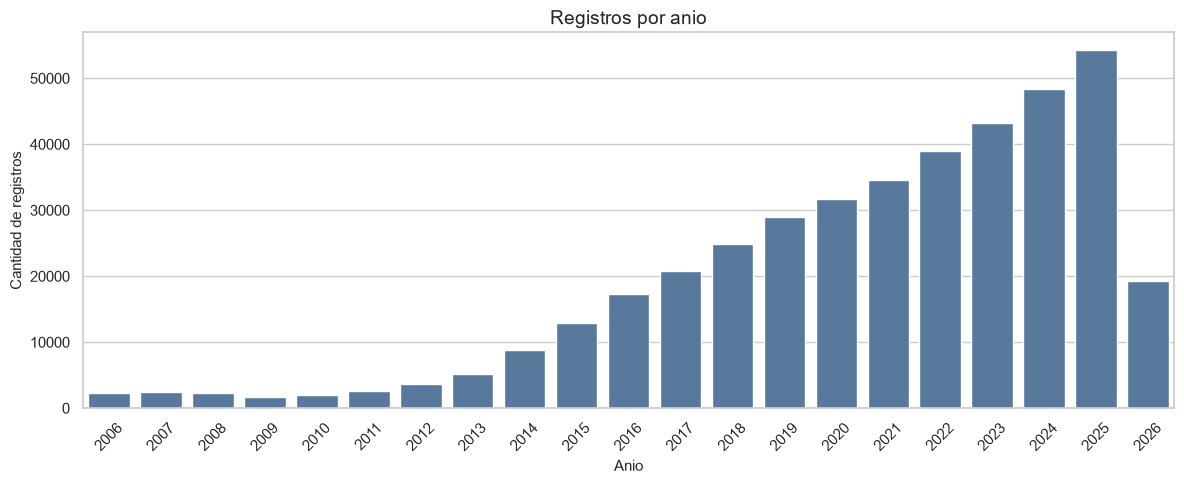

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=records_by_year, x="anio", y="registros", color="#4C78A8", ax=ax)
ax.set_title("Registros por anio")
ax.set_xlabel("Anio")
ax.set_ylabel("Cantidad de registros")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_registros_por_anio.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
monthly_coverage = (
    df_eda.groupby("periodo_mes")
    .agg(
        registros=("idpozo", "size"),
        pozos_activos=("idpozo", "nunique"),
    )
    .reset_index()
)

monthly_coverage.head(), monthly_coverage.tail()

(  periodo_mes  registros  pozos_activos
 0  2006-01-01        195            195
 1  2006-02-01        196            196
 2  2006-03-01        197            197
 3  2006-04-01        197            197
 4  2006-05-01        197            197,
     periodo_mes  registros  pozos_activos
 239  2025-12-01       4740           4740
 240  2026-01-01       4772           4772
 241  2026-02-01       4814           4814
 242  2026-03-01       4851           4851
 243  2026-04-01       4899           4899)

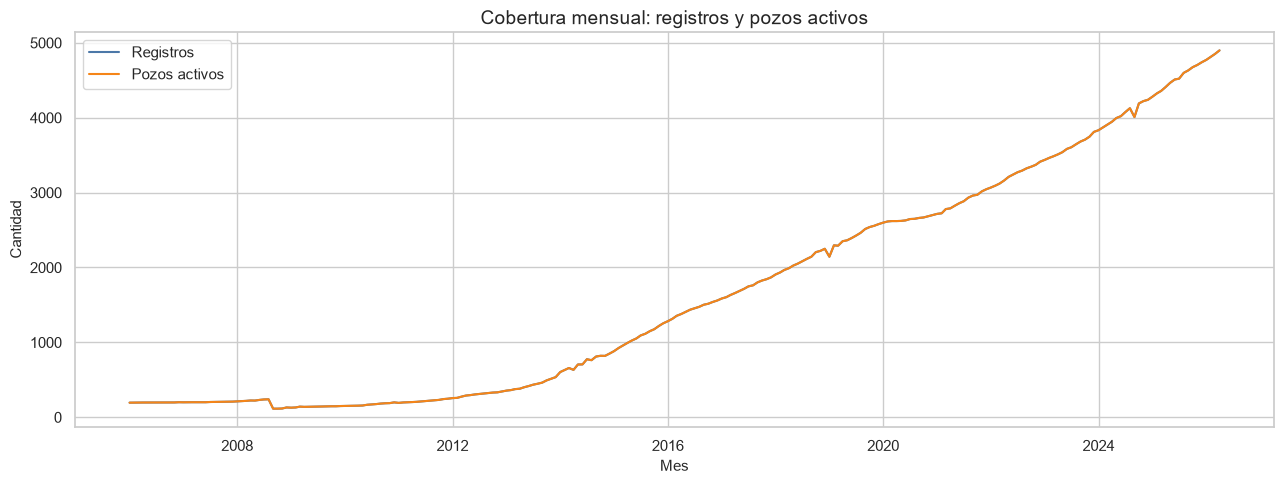

In [9]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly_coverage["periodo_mes"], monthly_coverage["registros"], label="Registros", color="#4C78A8")
ax.plot(monthly_coverage["periodo_mes"], monthly_coverage["pozos_activos"], label="Pozos activos", color="#F58518")
ax.set_title("Cobertura mensual: registros y pozos activos")
ax.set_xlabel("Mes")
ax.set_ylabel("Cantidad")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_cobertura_mensual.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Produccion mensual total

Se agregan las producciones mensuales de petroleo, gas y agua. Esta vista muestra escala y tendencia del sistema completo, pero no debe confundirse con productividad individual: el total mensual tambien depende de cuantos pozos activos hay en cada periodo.

In [10]:
monthly_production = (
    df_eda.groupby("periodo_mes")
    .agg(
        prod_pet=("prod_pet", "sum"),
        prod_gas=("prod_gas", "sum"),
        prod_agua=("prod_agua", "sum"),
        pozos_activos=("idpozo", "nunique"),
    )
    .reset_index()
)

monthly_production.head(), monthly_production.tail()

(  periodo_mes  prod_pet  prod_gas  prod_agua  pozos_activos
 0  2006-01-01  1,070.01 32,508.01     993.13            195
 1  2006-02-01    994.51 30,792.90     795.49            196
 2  2006-03-01  1,136.84 33,042.57     923.25            197
 3  2006-04-01  1,113.68 31,362.12     827.89            197
 4  2006-05-01  1,505.21 39,218.73   1,358.45            197,
     periodo_mes     prod_pet     prod_gas    prod_agua  pozos_activos
 239  2025-12-01 2,930,406.25 2,657,729.56 1,406,066.36           4740
 240  2026-01-01 2,974,829.39 2,657,696.52 1,491,857.05           4772
 241  2026-02-01 2,647,858.79 2,550,997.75 1,389,509.70           4814
 242  2026-03-01 2,964,369.98 2,950,482.46 1,627,173.84           4851
 243  2026-04-01 2,956,329.53 2,843,563.16 1,697,761.25           4899)

In [11]:
production_totals = pd.DataFrame(
    {
        "variable": ["prod_pet", "prod_gas", "prod_agua"],
        "produccion_total": [
            df_eda["prod_pet"].sum(),
            df_eda["prod_gas"].sum(),
            df_eda["prod_agua"].sum(),
        ],
        "mes_maximo": [
            monthly_production.loc[monthly_production["prod_pet"].idxmax(), "periodo_mes"],
            monthly_production.loc[monthly_production["prod_gas"].idxmax(), "periodo_mes"],
            monthly_production.loc[monthly_production["prod_agua"].idxmax(), "periodo_mes"],
        ],
        "valor_maximo_mensual": [
            monthly_production["prod_pet"].max(),
            monthly_production["prod_gas"].max(),
            monthly_production["prod_agua"].max(),
        ],
    }
)

production_totals

,variable,produccion_total,mes_maximo,valor_maximo_mensual
0,prod_pet,"131,169,463.56",2026-01-01,"2,974,829.39"
1,prod_gas,"254,976,883.43",2025-07-01,"3,311,426.85"
2,prod_agua,"73,975,822.41",2026-04-01,"1,697,761.25"


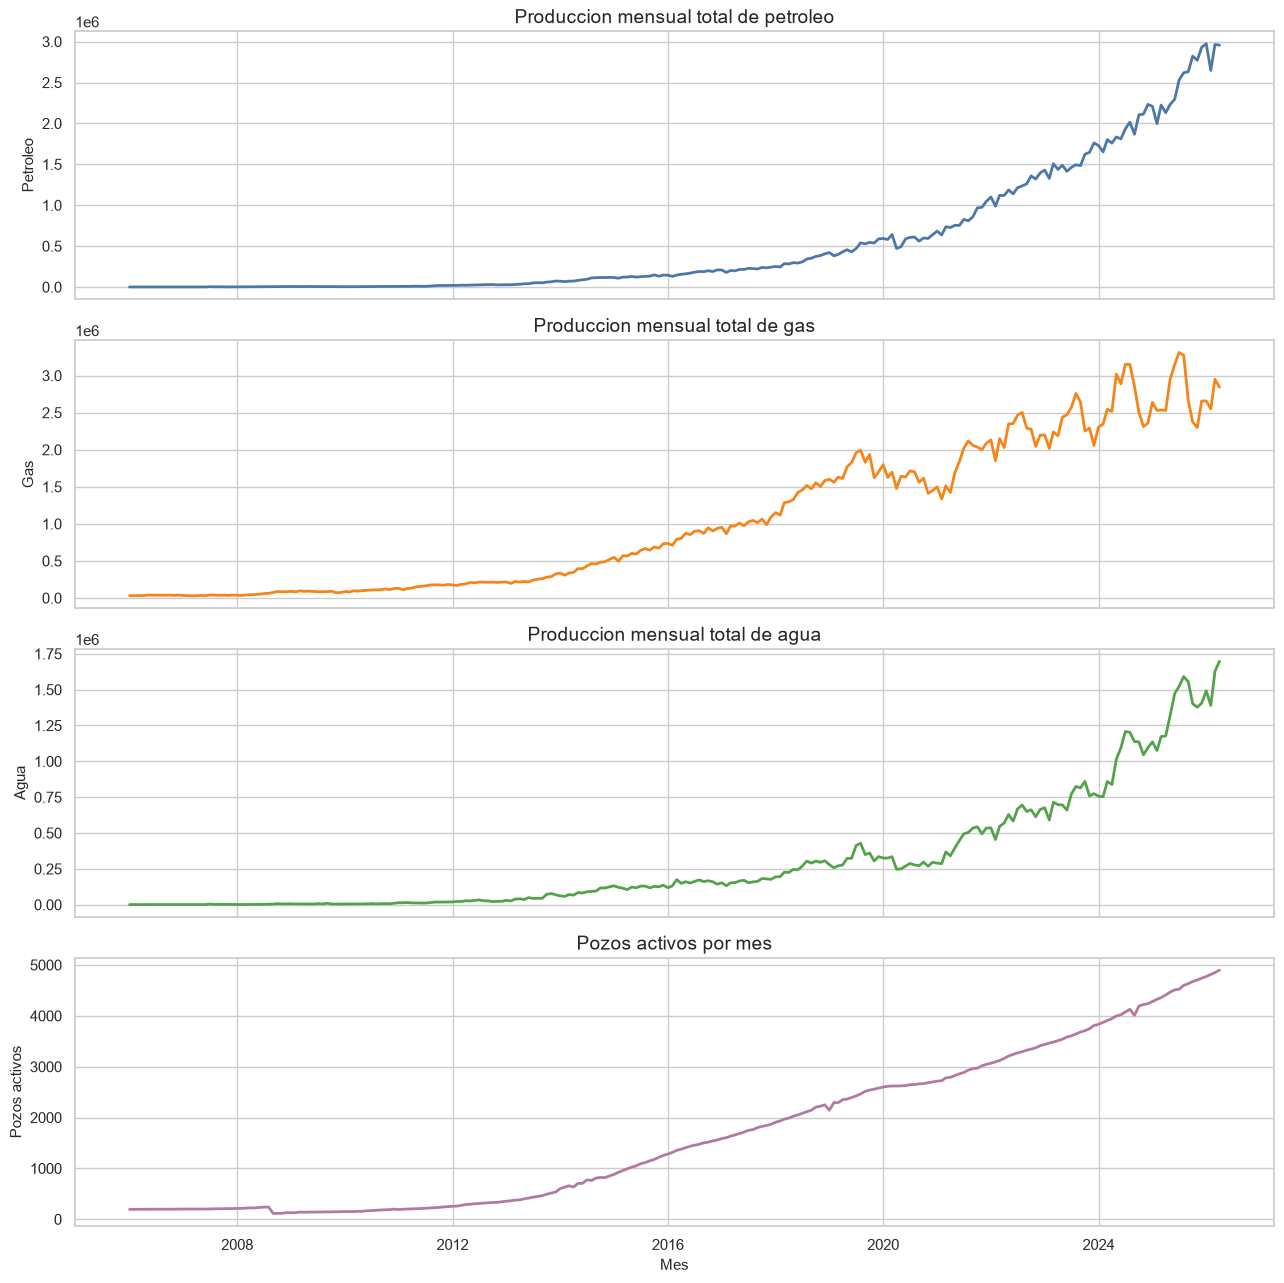

In [12]:
fig, axes = plt.subplots(4, 1, figsize=(13, 13), sharex=True)

series_config = [
    ("prod_pet", "Produccion mensual total de petroleo", "Petroleo", "#4C78A8"),
    ("prod_gas", "Produccion mensual total de gas", "Gas", "#F58518"),
    ("prod_agua", "Produccion mensual total de agua", "Agua", "#54A24B"),
    ("pozos_activos", "Pozos activos por mes", "Pozos activos", "#B279A2"),
]

for ax, (col, title, ylabel, color) in zip(axes, series_config):
    ax.plot(monthly_production["periodo_mes"], monthly_production[col], color=color, linewidth=2)
    ax.set_title(title)
    ax.set_ylabel(ylabel)

axes[-1].set_xlabel("Mes")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_produccion_mensual_total.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Produccion por categorias

Se agregan registros, pozos unicos y produccion por variables descriptivas. Esto permite identificar concentraciones geograficas, operativas y empresariales que pueden condicionar el EDA y el futuro modelado.

In [13]:
category_columns = [
    "provincia",
    "cuenca",
    "empresa",
    "tipo_de_recurso",
    "sub_tipo_recurso",
    "tipopozo",
    "tipoestado",
    "tipoextraccion",
]


def summarize_category(df_input: pd.DataFrame, category: str) -> pd.DataFrame:
    summary = (
        df_input.groupby(category, dropna=False)
        .agg(
            registros=("idpozo", "size"),
            pozos_unicos=("idpozo", "nunique"),
            prod_pet=("prod_pet", "sum"),
            prod_gas=("prod_gas", "sum"),
            prod_agua=("prod_agua", "sum"),
        )
        .reset_index()
        .sort_values("registros", ascending=False)
    )
    summary["pct_registros"] = summary["registros"] / summary["registros"].sum() * 100
    summary["pct_prod_pet"] = summary["prod_pet"] / summary["prod_pet"].sum() * 100
    summary["pct_prod_gas"] = summary["prod_gas"] / summary["prod_gas"].sum() * 100
    summary["pct_prod_agua"] = summary["prod_agua"] / summary["prod_agua"].sum() * 100
    return summary


category_summaries = {
    category: summarize_category(df_eda, category)
    for category in category_columns
    if category in df_eda.columns
}

list(category_summaries.keys())

['provincia',
 'cuenca',
 'empresa',
 'tipo_de_recurso',
 'sub_tipo_recurso',
 'tipopozo',
 'tipoestado',
 'tipoextraccion']

### 6.1 Provincia

In [14]:
category_summaries["provincia"]

,provincia,registros,pozos_unicos,prod_pet,prod_gas,prod_agua,pct_registros,pct_prod_pet,pct_prod_gas,pct_prod_agua
2,Neuquén,357889,4424,"127,817,991.29","232,167,793.41","71,343,214.09",88.15,97.44,91.05,96.44
3,Rio Negro,28713,245,"2,746,298.73","12,510,358.06","1,149,442.09",7.07,2.09,4.91,1.55
5,Santa Cruz,15899,220,"413,190.66","9,731,621.02","959,471.23",3.92,0.32,3.82,1.30
1,Mendoza,3057,33,"168,399.49","549,294.56","232,349.49",0.75,0.13,0.22,0.31
0,Chubut,253,4,"7,612.11","15,633.67","39,084.86",0.06,0.01,0.01,0.05
4,Salta,185,3,"15,971.30","2,182.71","252,260.65",0.05,0.01,0.00,0.34


### 6.2 Cuenca

In [15]:
category_summaries["cuenca"]

,cuenca,registros,pozos_unicos,prod_pet,prod_gas,prod_agua,pct_registros,pct_prod_pet,pct_prod_gas,pct_prod_agua
2,NEUQUINA,389659,4702,"130,732,689.50","245,227,446.03","72,725,005.67",95.98,99.67,96.18,98.31
0,AUSTRAL,15570,209,"303,493.07","9,420,908.93","853,384.74",3.84,0.23,3.69,1.15
1,GOLFO SAN JORGE,582,15,"117,309.69","326,345.76","145,171.35",0.14,0.09,0.13,0.20
3,NOROESTE,185,3,"15,971.30","2,182.71","252,260.65",0.05,0.01,0.00,0.34


### 6.3 Empresa

In [16]:
category_summaries["empresa"].head(15)

,empresa,registros,pozos_unicos,prod_pet,prod_gas,prod_agua,pct_registros,pct_prod_pet,pct_prod_gas,pct_prod_agua
53,YPF S.A.,221496,2651,"77,137,800.24","85,053,721.71","34,034,673.85",54.56,58.81,33.36,46.01
6,CAPEX S.A.,20705,177,"550,169.68","4,650,036.59","292,254.58",5.10,0.42,1.82,0.40
37,PLUSPETROL S.A.,20378,274,"4,472,919.41","16,689,233.98","4,490,737.05",5.02,3.41,6.55,6.07
28,PAN AMERICAN ENERGY SL,19109,316,"7,069,004.00","17,326,882.58","4,808,707.60",4.71,5.39,6.80,6.50
45,TOTAL AUSTRAL S.A.,15245,175,"1,462,623.89","26,496,515.43","4,072,323.94",3.75,1.12,10.39,5.50
9,COMPAÑÍA GENERAL DE COMBUSTIBLES S.A.,15232,226,"298,941.40","9,252,212.13","849,045.24",3.75,0.23,3.63,1.15
44,TECPETROL S.A.,14821,256,"3,893,749.96","42,008,042.48","7,950,337.21",3.65,2.97,16.48,10.75
26,PAMPA ENERGIA S.A.,12743,231,"1,034,018.33","23,090,021.04","2,401,278.73",3.14,0.79,9.06,3.25
42,SHELL ARGENTINA S.A.,8505,173,"9,238,627.40","1,413,559.98","1,363,671.60",2.09,7.04,0.55,1.84
54,YSUR ENERGÍA ARGENTINA S.R.L.,7721,241,"712,936.06","3,823,285.15","331,145.58",1.90,0.54,1.50,0.45


### 6.4 Tipo de recurso y subtipo de recurso

In [17]:
category_summaries["tipo_de_recurso"]

,tipo_de_recurso,registros,pozos_unicos,prod_pet,prod_gas,prod_agua,pct_registros,pct_prod_pet,pct_prod_gas,pct_prod_agua
0,NO CONVENCIONAL,405996,4929,"131,169,463.56","254,976,883.43","73,975,822.41",100.00,100.00,100.00,100.00


In [18]:
category_summaries["sub_tipo_recurso"]

,sub_tipo_recurso,registros,pozos_unicos,prod_pet,prod_gas,prod_agua,pct_registros,pct_prod_pet,pct_prod_gas,pct_prod_agua
0,SHALE,213916,3303,"126,419,844.39","149,782,920.99","64,366,224.59",52.69,96.38,58.74,87.01
1,TIGHT,191640,1622,"4,725,861.11","104,756,630.86","9,533,711.19",47.20,3.60,41.08,12.89
2,NaN,440,4,"23,758.06","437,331.58","75,886.63",0.11,0.02,0.17,0.10


### 6.5 Tipo de pozo, estado y sistema de extraccion

In [19]:
category_summaries["tipopozo"]

,tipopozo,registros,pozos_unicos,prod_pet,prod_gas,prod_agua,pct_registros,pct_prod_pet,pct_prod_gas,pct_prod_agua
0,Gasífero,221257,2448,"13,197,965.47","232,343,792.81","32,067,670.16",54.50,10.06,91.12,43.35
4,Petrolífero,156071,2565,"117,956,120.48","22,610,839.26","41,891,406.72",38.44,89.93,8.87,56.63
3,Otro tipo,27320,868,"14,316.24","19,923.17","15,056.15",6.73,0.01,0.01,0.02
5,Sumidero,644,24,558.22,142.26,83.07,0.16,0.00,0.00,0.00
6,NaN,605,192,0.00,0.00,0.00,0.15,0.00,0.00,0.00
1,Inyección de Agua,56,4,0.00,0.00,0.00,0.01,0.00,0.00,0.00
2,Inyección de Gas,43,7,503.16,"2,185.93","1,606.31",0.01,0.00,0.00,0.00


In [20]:
category_summaries["tipoestado"].head(15)

,tipoestado,registros,pozos_unicos,prod_pet,prod_gas,prod_agua,pct_registros,pct_prod_pet,pct_prod_gas,pct_prod_agua
9,Extracción Efectiva,335603,4790,"129,972,006.47","249,747,734.74","72,746,269.77",82.66,99.09,97.95,98.34
15,Parado Transitoriamente,25484,2279,"482,394.43","4,912,308.74","877,556.54",6.28,0.37,1.93,1.19
4,En Estudio,23206,523,"90,931.04","41,018.83","53,571.85",5.72,0.07,0.02,0.07
1,Abandonado,3521,299,498.79,47.45,214.81,0.87,0.00,0.00,0.00
0,A Abandonar,3483,125,"1,404.57","1,418.83",307.97,0.86,0.00,0.00,0.00
12,Otras Situación Inactivo,3198,451,"89,421.06","53,507.39","70,865.42",0.79,0.07,0.02,0.10
7,En Reserva de Gas,2966,141,"10,617.54","17,658.93","8,780.20",0.73,0.01,0.01,0.01
3,En Espera de Reparación,2583,95,546.63,509.50,"1,850.80",0.64,0.00,0.00,0.00
11,Otras Situación Activo,2264,128,"520,706.69","180,892.71","213,462.60",0.56,0.40,0.07,0.29
2,Abandono Temporario,840,20,0.00,0.00,0.00,0.21,0.00,0.00,0.00


In [21]:
category_summaries["tipoextraccion"].head(15)

,tipoextraccion,registros,pozos_unicos,prod_pet,prod_gas,prod_agua,pct_registros,pct_prod_pet,pct_prod_gas,pct_prod_agua
10,Surgencia Natural,261982,4772,"107,081,978.73","241,997,186.84","65,762,737.41",64.53,81.64,94.91,88.90
8,Plunger Lift,66789,793,"2,569,387.53","6,325,862.80","1,595,407.48",16.45,1.96,2.48,2.16
1,Bombeo Mecánico,44073,958,"11,293,132.22","1,916,514.13","2,521,226.98",10.86,8.61,0.75,3.41
9,Sin Sistema de Extracción,17747,997,"946,277.27","2,730,575.49","1,103,724.86",4.37,0.72,1.07,1.49
4,Gas Lift,13996,340,"8,764,719.10","1,904,556.15","2,646,802.46",3.45,6.68,0.75,3.58
11,NaN,605,192,0.00,0.00,0.00,0.15,0.00,0.00,0.00
0,Bombeo Hidráulico,336,18,"96,961.18","17,722.32","11,704.60",0.08,0.07,0.01,0.02
3,Electrosumergible,257,18,"363,779.71","58,123.00","66,699.94",0.06,0.28,0.02,0.09
5,Jet Pump,98,3,"16,824.72","2,223.78","252,311.32",0.02,0.01,0.00,0.34
6,Otros Tipos de Extracción,95,26,"34,215.43","24,109.25","13,410.99",0.02,0.03,0.01,0.02


## 7. Graficos por categorias

Se guardan graficos de barras con las categorias mas frecuentes. Para categorias con muchos valores, se muestran los primeros 10 grupos por cantidad de registros.

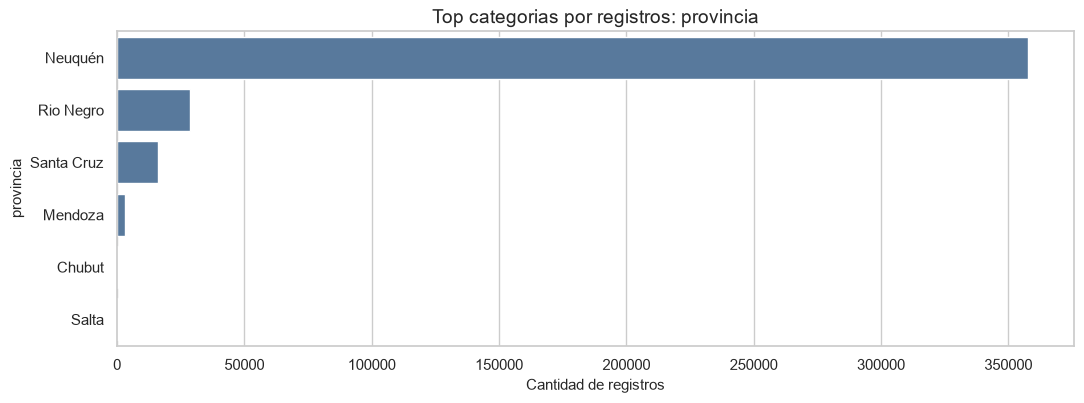

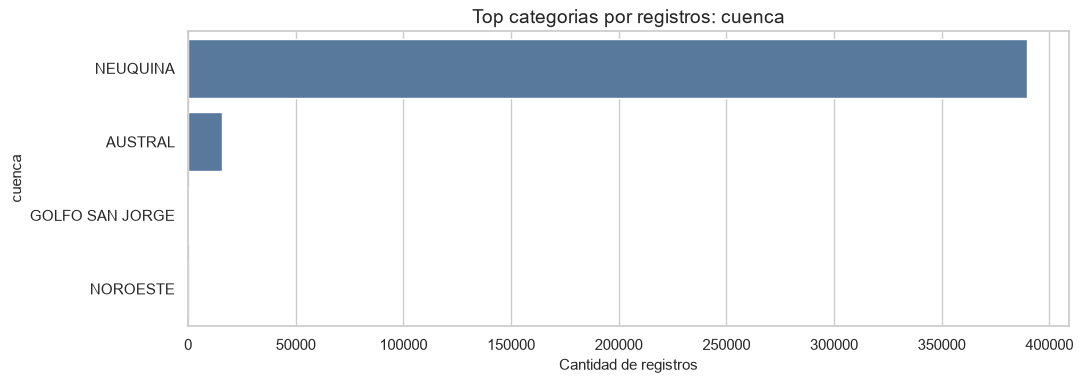

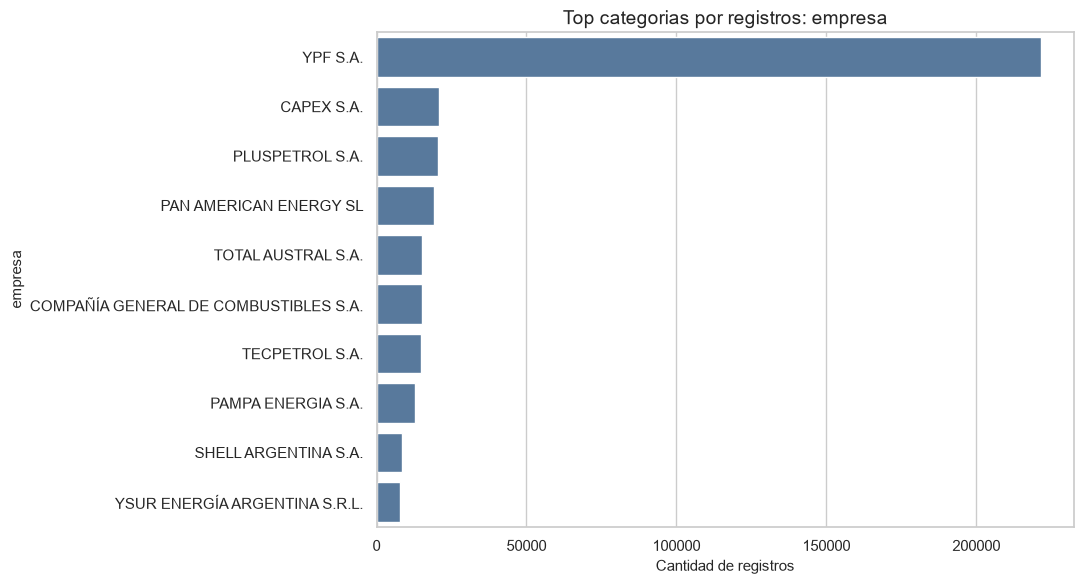

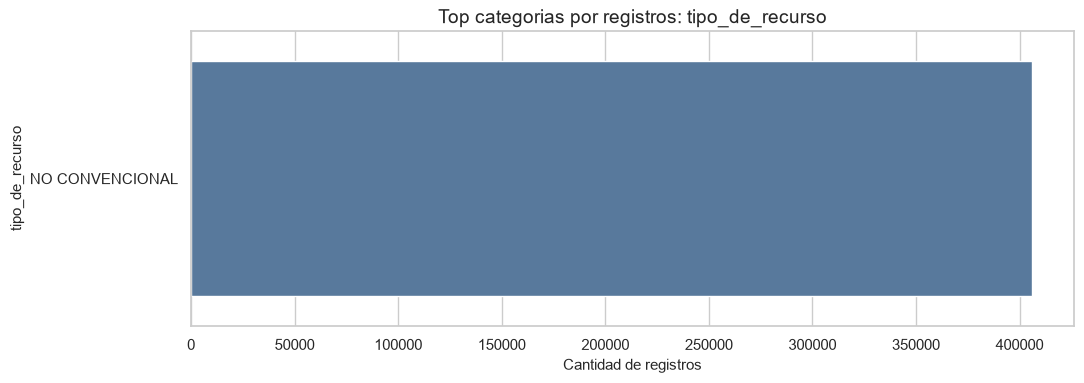

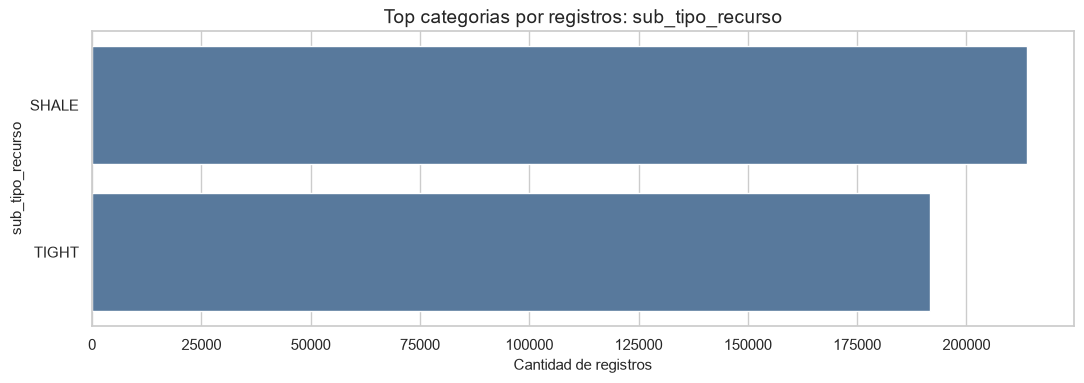

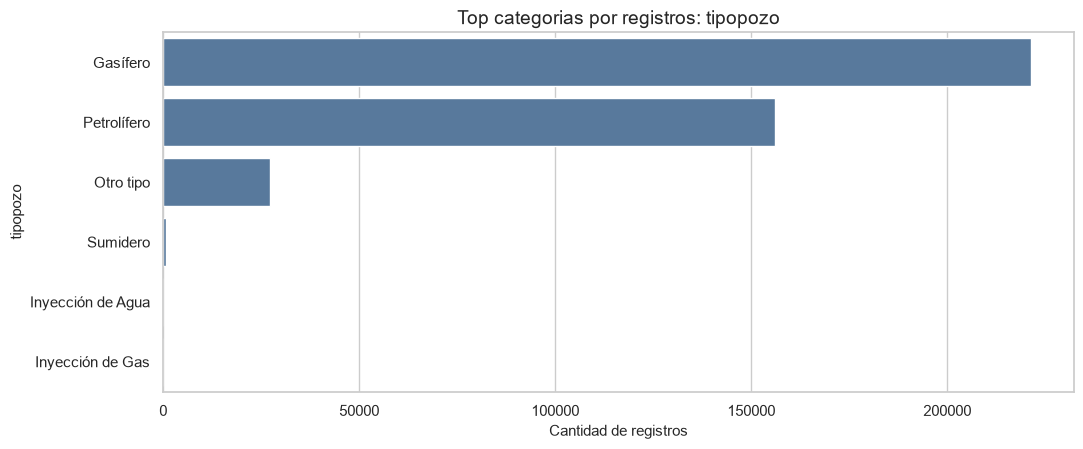

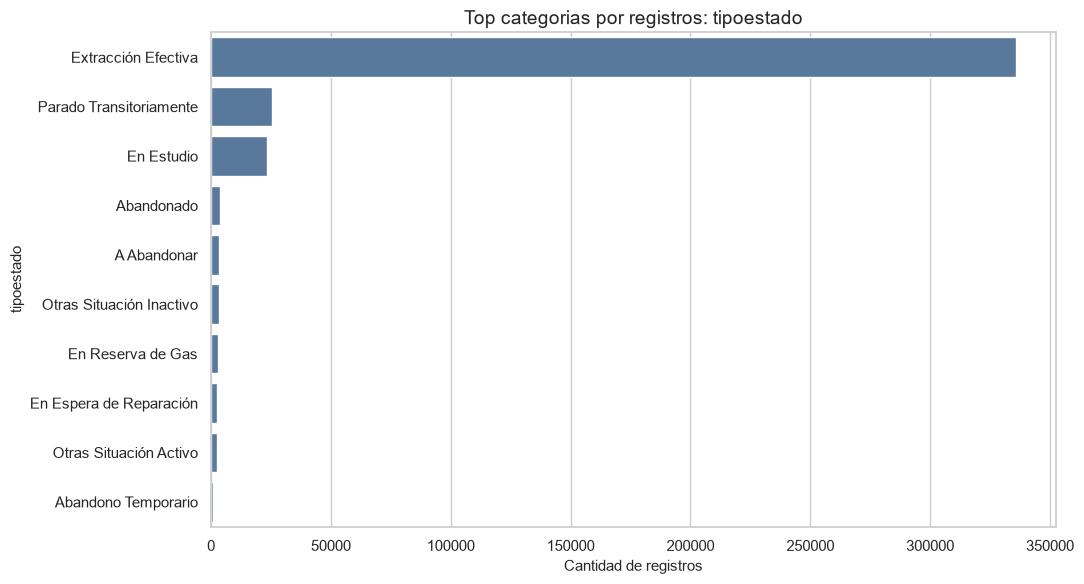

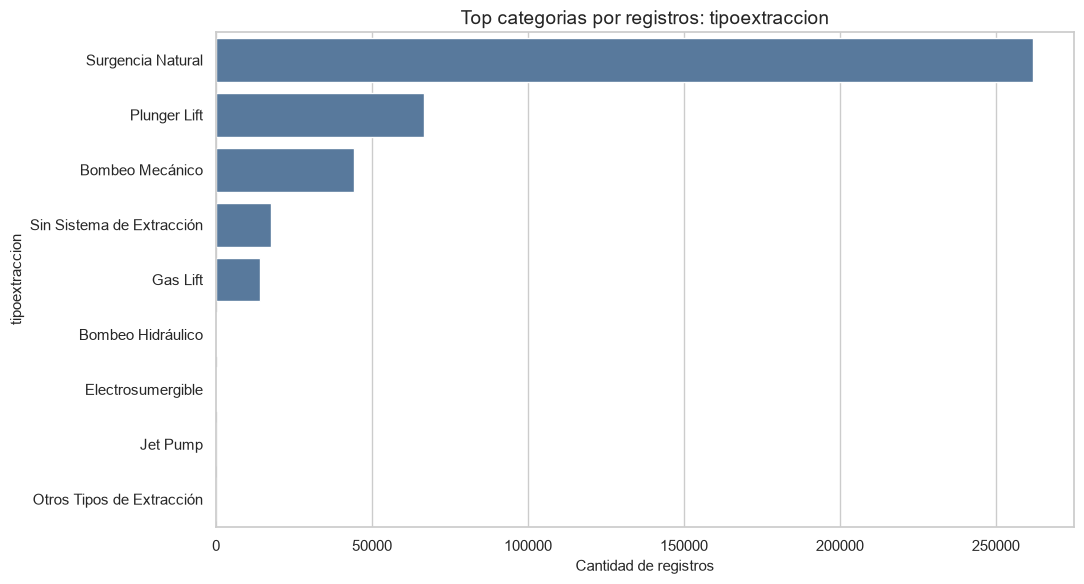

In [22]:
def plot_top_categories(summary: pd.DataFrame, category: str, top_n: int = 10) -> None:
    plot_data = summary.head(top_n).copy()
    plot_data[category] = plot_data[category].astype(str)

    fig_height = max(4, 0.45 * len(plot_data) + 1.5)
    fig, ax = plt.subplots(figsize=(11, fig_height))
    sns.barplot(
        data=plot_data,
        y=category,
        x="registros",
        color="#4C78A8",
        ax=ax,
    )
    ax.set_title(f"Top categorias por registros: {category}")
    ax.set_xlabel("Cantidad de registros")
    ax.set_ylabel(category)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"eda_top_{category}_por_registros.png", dpi=150, bbox_inches="tight")
    plt.show()


for category, summary in category_summaries.items():
    plot_top_categories(summary, category, top_n=10)

## 8. Produccion por categorias principales

Para complementar el conteo de registros, se grafican las contribuciones de petroleo, gas y agua por categorias estructurales clave. Esta comparacion ayuda a ver que una categoria puede tener muchos registros pero no necesariamente dominar todos los tipos de produccion.

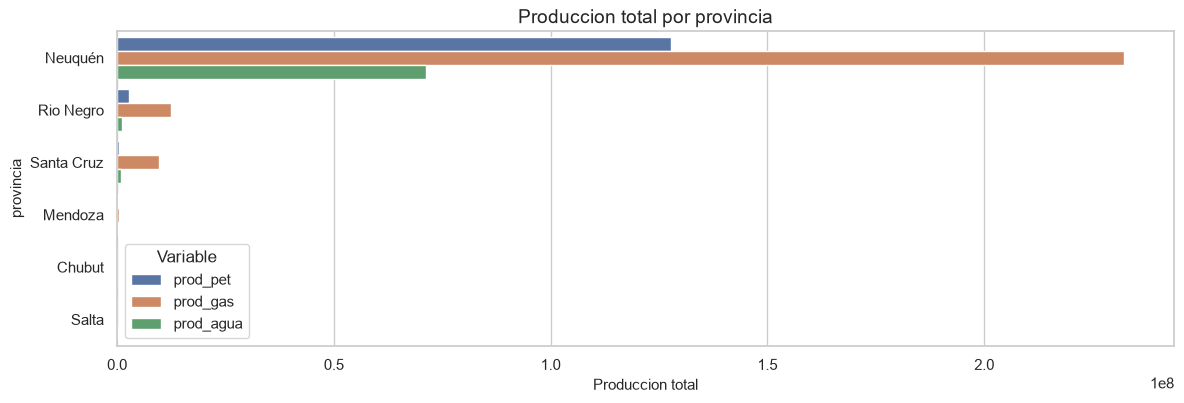

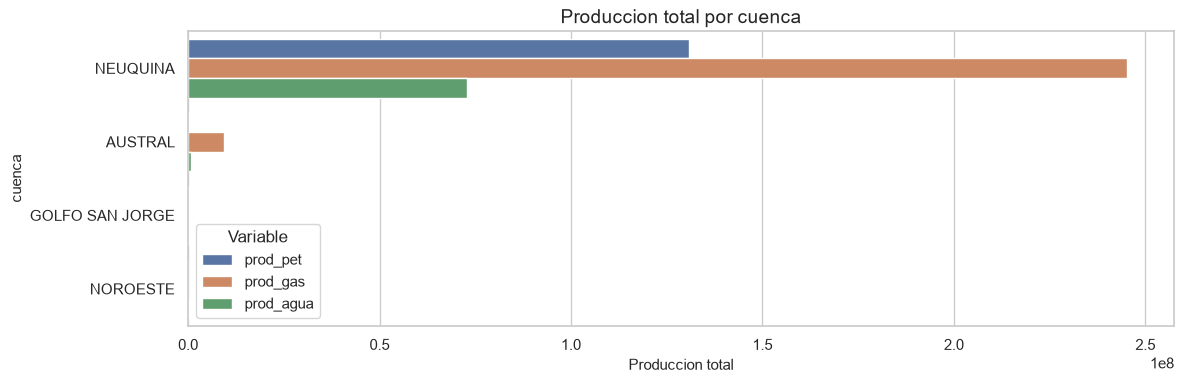

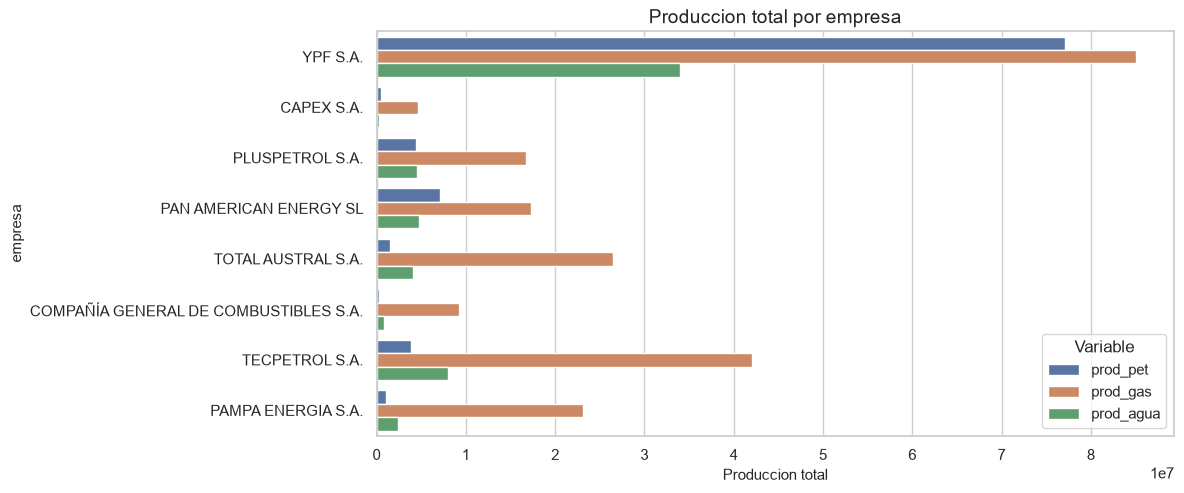

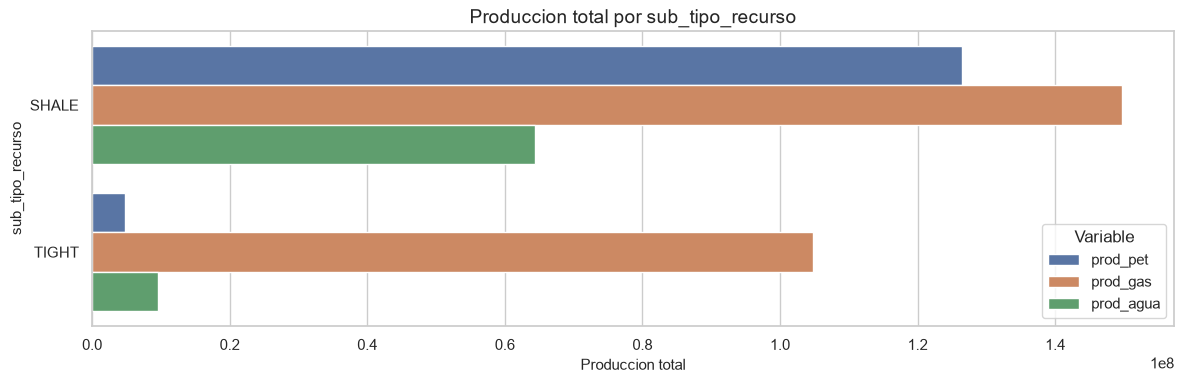

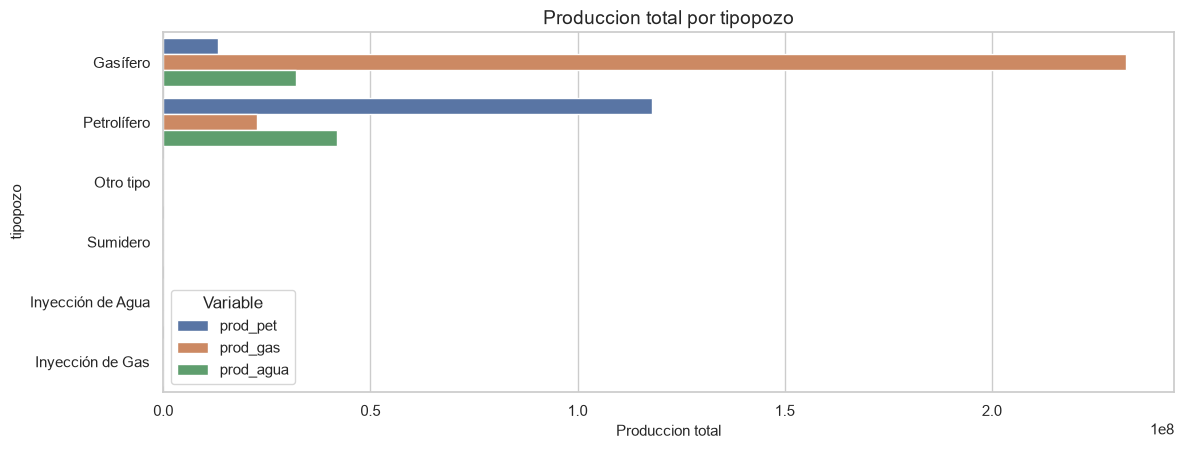

In [23]:
def plot_production_mix(summary: pd.DataFrame, category: str, top_n: int = 8) -> None:
    plot_data = summary.head(top_n).copy()
    plot_data[category] = plot_data[category].astype(str)
    long_data = plot_data.melt(
        id_vars=category,
        value_vars=["prod_pet", "prod_gas", "prod_agua"],
        var_name="variable",
        value_name="produccion_total",
    )

    fig_height = max(4, 0.45 * len(plot_data) + 1.5)
    fig, ax = plt.subplots(figsize=(12, fig_height))
    sns.barplot(
        data=long_data,
        y=category,
        x="produccion_total",
        hue="variable",
        ax=ax,
    )
    ax.set_title(f"Produccion total por {category}")
    ax.set_xlabel("Produccion total")
    ax.set_ylabel(category)
    ax.legend(title="Variable")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"eda_produccion_por_{category}.png", dpi=150, bbox_inches="tight")
    plt.show()


for category in ["provincia", "cuenca", "empresa", "sub_tipo_recurso", "tipopozo"]:
    plot_production_mix(category_summaries[category], category, top_n=8)

## 9. Figuras guardadas

Listado de archivos generados en `../reports/figures/` desde este notebook.

In [24]:
saved_figures = sorted(path.name for path in FIGURES_DIR.glob("eda_*.png"))
pd.DataFrame({"figura": saved_figures})

,figura
0,eda_cobertura_mensual.png
1,eda_produccion_mensual_total.png
2,eda_produccion_por_cuenca.png
3,eda_produccion_por_empresa.png
4,eda_produccion_por_provincia.png
5,eda_produccion_por_sub_tipo_recurso.png
6,eda_produccion_por_tipopozo.png
7,eda_registros_por_anio.png
8,eda_top_cuenca_por_registros.png
9,eda_top_empresa_por_registros.png


## Conclusiones parciales del EDA base

- **Rango temporal:** la base cubre desde enero de 2006 hasta abril de 2026. El anio 2026 es parcial porque solo contiene los meses de enero a abril.
- **Cobertura:** la cantidad de registros y pozos activos crece de forma marcada a lo largo del tiempo. En abril de 2026 se observa el maximo de pozos activos del dataset, con 4.899 pozos.
- **Produccion general:** la produccion mensual total aumenta fuertemente en los ultimos anios. El maximo mensual de petroleo aparece en enero de 2026, el maximo mensual de gas en julio de 2025 y el maximo mensual de agua en abril de 2026. Como los totales dependen de la cantidad de pozos activos, en etapas posteriores conviene analizar tambien metricas por pozo.
- **Categorias relevantes:** Neuquen concentra la mayor parte de los registros y de la produccion. La Cuenca Neuquina domina claramente frente al resto. A nivel empresa, YPF S.A. tiene la mayor participacion en registros. El dataset completo corresponde a recurso no convencional.
- **Subtipo de recurso:** `SHALE` concentra la mayor parte de la produccion de petroleo y una porcion importante del gas. `TIGHT` tiene menos peso petrolero, pero sigue siendo relevante para gas.
- **Tipo de pozo y estado:** los pozos gasiferos concentran la mayor parte del gas, mientras que los petroliferos concentran la mayor parte del petroleo. El estado `Extraccion Efectiva` domina los registros y la produccion.
- **Sistema de extraccion:** `Surgencia Natural` es el sistema mas frecuente y concentra gran parte de la produccion agregada, especialmente de gas.
- **Posibles sesgos o concentraciones:** existe una fuerte concentracion geografica, por cuenca, por operador y por estados operativos. Esto puede afectar la interpretacion de patrones y la evaluacion futura del modelo.
- **Advertencias para seguir el EDA:** no comparar meses recientes con meses antiguos sin considerar crecimiento de pozos activos; tratar 2026 como periodo parcial; revisar ceros y negativos detectados en calidad de datos; separar analisis de produccion total y produccion por pozo; evitar cualquier uso de informacion futura al construir el target o features temporales.

## 10. Distribuciones, ceros, negativos y comportamiento por pozo

Esta segunda parte del EDA profundiza en la calidad productiva del dataset. Se analizan distribuciones, outliers, valores negativos, producciones iguales a cero y comportamiento historico por pozo. No se crea el target definitivo, no se entrena ningun modelo y no se eliminan datos automaticamente.

### 10.1 Distribuciones de produccion

Las variables de produccion suelen tener colas largas: muchos registros con valores bajos o cero y pocos registros con valores muy altos. Para poder interpretar mejor la forma de las distribuciones se usan dos vistas complementarias: escala `log1p` y recorte visual al percentil 99. Estas transformaciones son solo para graficar; no modifican el dataset.

In [ ]:
production_cols = ["prod_pet", "prod_gas", "prod_agua"]

production_distribution_summary = df_eda[production_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T
production_distribution_summary["ceros"] = (df_eda[production_cols] == 0).sum()
production_distribution_summary["pct_ceros"] = (df_eda[production_cols] == 0).mean() * 100
production_distribution_summary["negativos"] = (df_eda[production_cols] < 0).sum()

production_distribution_summary

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, production_cols):
    values = df_eda.loc[df_eda[col] >= 0, col]
    sns.histplot(np.log1p(values), bins=60, ax=ax, color="#4C78A8")
    ax.set_title(f"Histograma de {col} en escala log1p")
    ax.set_xlabel(f"log1p({col})")
    ax.set_ylabel("Cantidad de registros")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_10_hist_produccion_log1p.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, production_cols):
    values = df_eda.loc[df_eda[col] >= 0, col]
    upper_limit = values.quantile(0.99)
    sns.histplot(values.clip(upper=upper_limit), bins=60, ax=ax, color="#54A24B")
    ax.set_title(f"Histograma de {col} recortado al p99")
    ax.set_xlabel(f"{col} recortado al percentil 99")
    ax.set_ylabel("Cantidad de registros")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_10_hist_produccion_p99.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
production_long_log = df_eda[production_cols].copy()

for col in production_cols:
    production_long_log[col] = np.where(production_long_log[col] >= 0, np.log1p(production_long_log[col]), np.nan)

production_long_log = production_long_log.melt(var_name="variable", value_name="valor_log1p")

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=production_long_log, x="variable", y="valor_log1p", ax=ax, color="#F58518")
ax.set_title("Boxplots de produccion en escala log1p")
ax.set_xlabel("Variable de produccion")
ax.set_ylabel("log1p(produccion)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_10_boxplot_produccion_log1p.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretacion.** Las variables `prod_pet`, `prod_gas` y `prod_agua` presentan distribuciones muy asimetricas y con outliers importantes. La escala `log1p` permite visualizar mejor la concentracion de registros en valores bajos, mientras que el recorte al percentil 99 permite observar la forma general sin que unos pocos valores extremos dominen completamente la escala.

### 10.2 Valores negativos

Se identifican registros con produccion negativa. Estos casos no se corrigen automaticamente en esta etapa: se reportan para revisarlos antes del modelado y antes de calcular variaciones mensuales o el target futuro.

In [ ]:
negative_summary = pd.DataFrame(
    {
        "variable": production_cols,
        "casos_negativos": [(df_eda[col] < 0).sum() for col in production_cols],
        "pct_negativos": [(df_eda[col] < 0).mean() * 100 for col in production_cols],
        "valor_minimo": [df_eda[col].min() for col in production_cols],
    }
)

negative_summary

In [ ]:
negative_display_cols = [
    "idpozo", "anio", "mes", "fecha_data", "empresa", "provincia", "cuenca",
    "areayacimiento", "tipoestado", "tipoextraccion", "tipopozo",
    "sub_tipo_recurso", "prod_pet", "prod_gas", "prod_agua",
]
negative_display_cols = [col for col in negative_display_cols if col in df_eda.columns]

prod_pet_negative_rows = df_eda.loc[df_eda["prod_pet"] < 0, negative_display_cols]
prod_pet_negative_rows

In [ ]:
prod_gas_negative_rows = df_eda.loc[df_eda["prod_gas"] < 0, negative_display_cols]
prod_gas_negative_rows

In [ ]:
prod_agua_negative_rows = df_eda.loc[df_eda["prod_agua"] < 0, negative_display_cols]
prod_agua_negative_rows

**Interpretacion.** Los negativos son muy pocos en relacion con el volumen total de registros. Aun asi, deben revisarse antes de cualquier etapa de modelado, porque pueden distorsionar calculos de variacion porcentual, lags, medias moviles y umbrales de caida.

### 10.3 Produccion igual a cero

Los ceros pueden ser informativos: pueden reflejar pozos parados, abandonados, en estudio, sin extraccion efectiva o pozos cuyo producto principal no corresponde a esa variable. Por eso se cuantifican y se cruzan con variables operativas y descriptivas.

In [ ]:
zero_summary = pd.DataFrame(
    {
        "variable": production_cols,
        "ceros": [(df_eda[col] == 0).sum() for col in production_cols],
        "pct_ceros": [(df_eda[col] == 0).mean() * 100 for col in production_cols],
        "no_ceros": [(df_eda[col] != 0).sum() for col in production_cols],
    }
)

zero_summary

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=zero_summary, x="variable", y="pct_ceros", color="#4C78A8", ax=ax)
ax.set_title("Porcentaje de registros con produccion igual a cero")
ax.set_xlabel("Variable")
ax.set_ylabel("Registros con cero (%)")
ax.set_ylim(0, max(45, zero_summary["pct_ceros"].max() * 1.15))
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_10_ceros_por_variable.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
def zero_cross_summary(df_input: pd.DataFrame, category: str, top_n: int = 15) -> pd.DataFrame:
    rows = []
    for category_value, group in df_input.groupby(category, dropna=False):
        row = {
            category: category_value,
            "registros": len(group),
            "pozos_unicos": group["idpozo"].nunique(),
        }
        for col in production_cols:
            row[f"ceros_{col}"] = int((group[col] == 0).sum())
            row[f"pct_ceros_{col}"] = float((group[col] == 0).mean() * 100)
        rows.append(row)
    return (
        pd.DataFrame(rows)
        .sort_values("registros", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


zero_cross_categories = ["tipoestado", "tipopozo", "tipo_de_recurso", "sub_tipo_recurso"]
zero_cross_tables = {
    category: zero_cross_summary(df_eda, category)
    for category in zero_cross_categories
    if category in df_eda.columns
}

zero_cross_tables["tipoestado"]

In [ ]:
zero_cross_tables["tipopozo"]

In [ ]:
zero_cross_tables["tipo_de_recurso"]

In [ ]:
zero_cross_tables["sub_tipo_recurso"]

In [ ]:
for category, table in zero_cross_tables.items():
    plot_data = table.melt(
        id_vars=[category, "registros", "pozos_unicos"],
        value_vars=[f"pct_ceros_{col}" for col in production_cols],
        var_name="variable",
        value_name="pct_ceros",
    )
    plot_data[category] = plot_data[category].astype(str)
    plot_data["variable"] = plot_data["variable"].str.replace("pct_ceros_", "", regex=False)

    fig_height = max(4, 0.45 * table.shape[0] + 1.5)
    fig, ax = plt.subplots(figsize=(12, fig_height))
    sns.barplot(data=plot_data, y=category, x="pct_ceros", hue="variable", ax=ax)
    ax.set_title(f"Porcentaje de ceros por {category}")
    ax.set_xlabel("Registros con cero (%)")
    ax.set_ylabel(category)
    ax.legend(title="Variable")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"eda_10_ceros_por_{category}.png", dpi=150, bbox_inches="tight")
    plt.show()

**Interpretacion.** La produccion igual a cero es frecuente y no tiene una unica lectura. Puede reflejar falta de actividad, estado operativo, etapa de vida del pozo o simplemente que el pozo produce principalmente otro fluido. Estos registros no deben eliminarse automaticamente porque pueden contener informacion relevante para explicar futuras caidas o inactividad.

### 10.4 Comportamiento por pozo

Se analiza la historia disponible por `idpozo`, la produccion acumulada y la presencia de meses con `prod_pet = 0` y `prod_gas = 0`. Esta revision es importante porque el problema final requiere construir informacion temporal por pozo.

In [ ]:
well_summary = (
    df_eda.groupby("idpozo")
    .agg(
        meses_disponibles=("periodo_mes", "nunique"),
        fecha_min=("fecha_data", "min"),
        fecha_max=("fecha_data", "max"),
        prod_pet_acum=("prod_pet", "sum"),
        prod_gas_acum=("prod_gas", "sum"),
        prod_agua_acum=("prod_agua", "sum"),
        meses_prod_pet_cero=("prod_pet", lambda s: int((s == 0).sum())),
        meses_prod_gas_cero=("prod_gas", lambda s: int((s == 0).sum())),
        meses_prod_agua_cero=("prod_agua", lambda s: int((s == 0).sum())),
    )
    .reset_index()
)

hydrocarbon_zero_by_well = (
    df_eda.assign(pet_y_gas_cero=(df_eda["prod_pet"] == 0) & (df_eda["prod_gas"] == 0))
    .groupby("idpozo")["pet_y_gas_cero"]
    .sum()
    .rename("meses_pet_y_gas_cero")
    .reset_index()
)

well_summary = well_summary.merge(hydrocarbon_zero_by_well, on="idpozo", how="left")

for col in ["prod_pet", "prod_gas", "prod_agua"]:
    well_summary[f"pct_meses_{col}_cero"] = well_summary[f"meses_{col}_cero"] / well_summary["meses_disponibles"] * 100

well_summary["pct_meses_pet_y_gas_cero"] = well_summary["meses_pet_y_gas_cero"] / well_summary["meses_disponibles"] * 100

well_history_summary = well_summary["meses_disponibles"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).to_frame()

well_history_summary

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.histplot(well_summary["meses_disponibles"], bins=50, color="#4C78A8", ax=ax)
ax.set_title("Distribucion de meses disponibles por pozo")
ax.set_xlabel("Meses disponibles")
ax.set_ylabel("Cantidad de pozos")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_10_meses_por_pozo_hist.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
short_history_threshold = 6
short_history_wells = well_summary.loc[
    well_summary["meses_disponibles"] <= short_history_threshold
].sort_values(["meses_disponibles", "fecha_max"])

short_history_summary = pd.DataFrame(
    {
        "umbral_meses_historial_corto": [short_history_threshold],
        "pozos_con_historial_corto": [len(short_history_wells)],
        "pct_pozos_con_historial_corto": [len(short_history_wells) / len(well_summary) * 100],
    }
)

short_history_summary

In [ ]:
short_history_wells.head(30)

In [ ]:
top20_wells_pet = well_summary.sort_values("prod_pet_acum", ascending=False).head(20)
top20_wells_pet

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))
plot_data = top20_wells_pet.sort_values("prod_pet_acum", ascending=True).copy()
plot_data["idpozo"] = plot_data["idpozo"].astype(str)
ax.barh(plot_data["idpozo"], plot_data["prod_pet_acum"], color="#4C78A8")
ax.set_title("Top 20 pozos por produccion acumulada de petroleo")
ax.set_xlabel("Produccion acumulada de petroleo")
ax.set_ylabel("idpozo")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_10_top20_pozos_prod_pet.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
top20_wells_gas = well_summary.sort_values("prod_gas_acum", ascending=False).head(20)
top20_wells_gas

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))
plot_data = top20_wells_gas.sort_values("prod_gas_acum", ascending=True).copy()
plot_data["idpozo"] = plot_data["idpozo"].astype(str)
ax.barh(plot_data["idpozo"], plot_data["prod_gas_acum"], color="#F58518")
ax.set_title("Top 20 pozos por produccion acumulada de gas")
ax.set_xlabel("Produccion acumulada de gas")
ax.set_ylabel("idpozo")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_10_top20_pozos_prod_gas.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
zero_heavy_wells = well_summary.sort_values(
    ["pct_meses_pet_y_gas_cero", "meses_pet_y_gas_cero", "meses_disponibles"],
    ascending=[False, False, False],
).head(30)

zero_heavy_wells

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
plot_data = zero_heavy_wells.head(20).sort_values("pct_meses_pet_y_gas_cero", ascending=True).copy()
plot_data["idpozo"] = plot_data["idpozo"].astype(str)
ax.barh(plot_data["idpozo"], plot_data["pct_meses_pet_y_gas_cero"], color="#B279A2")
ax.set_title("Top 20 pozos con mayor porcentaje de meses sin petroleo ni gas")
ax.set_xlabel("Meses con prod_pet = 0 y prod_gas = 0 (%)")
ax.set_ylabel("idpozo")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_10_pozos_muchos_meses_cero.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretacion.** La historia disponible varia mucho entre pozos. Los pozos con pocos meses disponibles pueden no tener suficiente informacion para calcular lags, medias moviles o tendencias. Tambien existen pozos con muchos meses sin produccion de petroleo ni gas, que deberian analizarse con cuidado para distinguir inactividad de caidas productivas reales.

### 10.5 Figuras guardadas de esta seccion

In [ ]:
eda_10_figures = sorted(path.name for path in FIGURES_DIR.glob("eda_10_*.png"))
pd.DataFrame({"figura": eda_10_figures})

## Conclusiones sobre distribuciones y calidad productiva

- **Sesgo y outliers:** `prod_pet`, `prod_gas` y `prod_agua` estan fuertemente sesgadas hacia la derecha. Hay muchos registros con valores bajos o cero y pocos registros con valores muy altos. Por eso se usaron escala `log1p` y recorte al percentil 99 como recursos visuales para interpretar la distribucion sin eliminar observaciones.
- **Ceros:** `prod_pet` tiene 144.047 registros en cero, equivalentes al 35,48% del dataset; `prod_gas` tiene 83.800 registros en cero, equivalentes al 20,64%; y `prod_agua` tiene 122.426 registros en cero, equivalentes al 30,15%. Estos ceros pueden responder a causas operativas como pozos parados, abandonados, en estudio, sin extraccion efectiva o pozos cuyo producto principal no es esa variable.
- **Negativos:** se detectaron 1 valor negativo en `prod_pet`, 2 valores negativos en `prod_gas` y 0 valores negativos en `prod_agua`. Son casos aislados frente al volumen total de datos, pero deberian revisarse antes del modelado y antes de calcular variaciones mensuales.
- **Meses disponibles por pozo:** la historia por pozo es heterogenea. La mediana es de 80 meses disponibles, el promedio es de 82,37 meses, el minimo es 1 mes y el maximo es 244 meses. Hay pozos con historial largo y tambien pozos con historial corto.
- **Pozos con historial corto:** se identificaron 233 pozos con 6 meses o menos de historia, equivalentes al 4,73% de los pozos. Estos casos pueden afectar la construccion de lags, medias moviles y tendencias, porque no siempre habra suficiente informacion historica disponible.
- **Implicancias para `caida_critica`:** no conviene definir el target directamente sobre `prod_pet` para todos los pozos ni directamente sobre `prod_gas` para todos los pozos sin considerar `tipopozo` y el producto principal del pozo. Una recomendacion metodologica es analizar una variable de produccion principal por pozo antes de definir el target. El siguiente paso deberia ser estudiar variaciones mensuales por pozo y evaluar umbrales razonables de caida critica, evitando data leakage y respetando el orden temporal.